In [ ]:
# Bài thực hành

In [1]:
import torch

print('GPU có sẵn không?', torch.cuda.is_available())
print('Phiên bản PyTorch:', torch.__version__)

if torch.cuda.is_available():
    print('Số GPU:', torch.cuda.device_count())
    print('Device đang dùng:', torch.cuda.current_device())   # nhớ có ()
    print('Tên GPU:', torch.cuda.get_device_name(0))
    print(f'Bộ nhớ đã cấp phát: {torch.cuda.memory_allocated() / 1e6:.2f} MB')
    print(f'Bộ nhớ được giữ:    {torch.cuda.memory_reserved()  / 1e6:.2f} MB')
    # Lưu ý: hàm `memory_cached` đã bị deprecated từ PyTorch 1.6, dùng `memory_reserved` thay thế.
else:
    print('Không có GPU — sẽ chạy trên CPU. Vẫn ổn cho các bài lab nhỏ.')

# Khai báo device để dùng xuyên suốt notebook.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('\nDevice sẽ dùng:', device)

GPU có sẵn không? False
Phiên bản PyTorch: 2.11.0+cpu
Không có GPU — sẽ chạy trên CPU. Vẫn ổn cho các bài lab nhỏ.

Device sẽ dùng: cpu


In [2]:
import numpy as np
torch.manual_seed(42)

# Một số cách phổ biến để tạo tensor.
a = torch.tensor([1, 2, 3])                  # từ list Python
b = torch.zeros(2, 3)                        # ma trận 2×3 toàn 0
c = torch.ones(3)                            # vector 3 phần tử toàn 1
d = torch.empty(2, 2)                        # cấp phát chỗ nhưng chưa khởi tạo (giá trị rác)
e = torch.randn(2, 3)                        # phân phối chuẩn N(0, 1)
f = torch.arange(0, 10, 2)                   # 0, 2, 4, 6, 8
g = torch.linspace(0, 1, 5)                  # 5 số đều nhau từ 0 đến 1

print('a =', a)
print('b =\n', b)
print('c =', c)
print('e =\n', e)
print('f =', f)
print('g =', g)

# In các thuộc tính quan trọng.
print('\nthuộc tính của e:')
print('  shape:', e.shape)
print('  dtype:', e.dtype)
print('  device:', e.device)

a = tensor([1, 2, 3])
b =
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
c = tensor([1., 1., 1.])
e =
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])
f = tensor([0, 2, 4, 6, 8])
g = tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])

thuộc tính của e:
  shape: torch.Size([2, 3])
  dtype: torch.float32
  device: cpu


In [3]:
arr = np.arange(0, 5)
t1 = torch.from_numpy(arr)   # chia sẻ bộ nhớ
t2 = torch.tensor(arr)       # copy

print('Trước khi sửa arr:')
print('  arr =', arr)
print('  t1  =', t1)
print('  t2  =', t2)

arr[0] = 99   # đổi giá trị đầu tiên của arr
print('\nSau khi sửa arr[0] = 99:')
print('  arr =', arr)
print('  t1  =', t1, '  ← thay đổi vì from_numpy chia sẻ bộ nhớ')
print('  t2  =', t2, '  ← không đổi vì tensor() đã copy')

Trước khi sửa arr:
  arr = [0 1 2 3 4]
  t1  = tensor([0, 1, 2, 3, 4])
  t2  = tensor([0, 1, 2, 3, 4])

Sau khi sửa arr[0] = 99:
  arr = [99  1  2  3  4]
  t1  = tensor([99,  1,  2,  3,  4])   ← thay đổi vì from_numpy chia sẻ bộ nhớ
  t2  = tensor([0, 1, 2, 3, 4])   ← không đổi vì tensor() đã copy


In [4]:
x = torch.arange(12)
print('Original:', x.shape)

y1 = x.view(3, 4)
y2 = x.reshape(3, 4)
y3 = x.view(-1, 4)   # -1 là "tự tính cho khớp"

print('view(3,4):\n', y1)
print('view(-1,4):\n', y3)

Original: torch.Size([12])
view(3,4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
view(-1,4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


In [5]:
x = torch.randn(3, 3)
print('Trên CPU:', x.device)

x = x.to(device)
print('Sau .to(device):', x.device)

Trên CPU: cpu
Sau .to(device): cpu


In [6]:
x = torch.tensor(2.0, requires_grad=True)   # bật autograd cho biến này
y = 2*x**4 + x**3 + 3*x**2 + 5*x + 1
print(f'y = {y.item()}')

y.backward()              # tính đạo hàm dy/dx và lưu vào x.grad
print(f'dy/dx tại x=2: {x.grad.item()}')

y = 63.0
dy/dx tại x=2: 93.0


In [7]:
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
f = a**2 + 3*a*b + b**3
f.backward()
print(f'df/da = {a.grad.item()}   (mong đợi 13)')
print(f'df/db = {b.grad.item()}   (mong đợi 33)')

df/da = 13.0   (mong đợi 13)
df/db = 33.0   (mong đợi 33)


In [8]:
x = torch.tensor(1.0, requires_grad=True)
for i in range(3):
    y = x ** 2
    y.backward()
    print(f'Lần {i+1}: x.grad = {x.grad.item()}  (gradient bị cộng dồn!)')

print('\nGiờ thử zero_grad sau mỗi bước:')
x = torch.tensor(1.0, requires_grad=True)
for i in range(3):
    if x.grad is not None:
        x.grad.zero_()
    y = x ** 2
    y.backward()
    print(f'Lần {i+1}: x.grad = {x.grad.item()}')

Lần 1: x.grad = 2.0  (gradient bị cộng dồn!)
Lần 2: x.grad = 4.0  (gradient bị cộng dồn!)
Lần 3: x.grad = 6.0  (gradient bị cộng dồn!)

Giờ thử zero_grad sau mỗi bước:
Lần 1: x.grad = 2.0
Lần 2: x.grad = 2.0
Lần 3: x.grad = 2.0


step  0: x = 0.6000, y = 10.0000
step  5: x = 2.2136, y = 1.9664
step 10: x = 2.7423, y = 1.1038
step 15: x = 2.9156, y = 1.0111
step 20: x = 2.9723, y = 1.0012
step 25: x = 2.9909, y = 1.0001
step 29: x = 2.9963, y = 1.0000


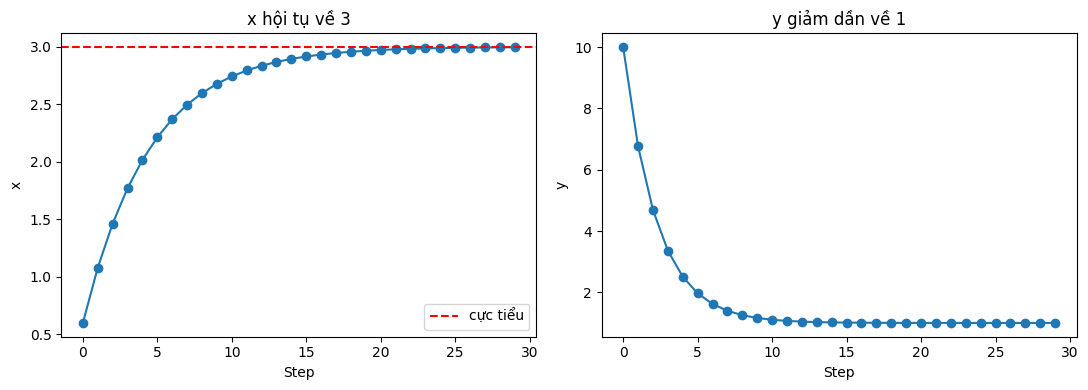

In [9]:
import matplotlib.pyplot as plt

x = torch.tensor(0.0, requires_grad=True)
lr = 0.1
history = []

for step in range(30):
    y = (x - 3)**2 + 1
    y.backward()

    # Cập nhật x bằng gradient descent.
    # `with torch.no_grad()` để tắt việc track autograd cho phép cập nhật này
    # — vì cập nhật trọng số không cần được đưa vào graph tính đạo hàm.
    with torch.no_grad():
        x -= lr * x.grad
        x.grad.zero_()           # phải zero_grad sau khi cập nhật

    history.append((x.item(), y.item()))
    if step % 5 == 0 or step == 29:
        print(f'step {step:2d}: x = {x.item():.4f}, y = {y.item():.4f}')

xs, ys = zip(*history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(xs, 'o-'); axes[0].axhline(3, color='red', linestyle='--', label='cực tiểu')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('x'); axes[0].legend(); axes[0].set_title('x hội tụ về 3')
axes[1].plot(ys, 'o-'); axes[1].set_xlabel('Step'); axes[1].set_ylabel('y'); axes[1].set_title('y giảm dần về 1')
plt.tight_layout(); plt.show()

In [ ]:
# Bài tập về nhà

In [ ]:
# Bài 1:

--- PHẦN 1: TÍNH ĐẠO HÀM TẠI X = 2 ---
Kết quả tính bằng PyTorch: dy/dx = 25.0
Kết quả tính bằng tay   : dy/dx = 3*4 + 4*2 + 5 = 25.0
=> Nhận xét: Hai kết quả hoàn toàn trùng khớp với nhau.

--- PHẦN 2: QUÁ TRÌNH GRADIENT DESCENT ---
Giá trị x sau 50 vòng lặp: -1.2835
Giá trị y sau 50 vòng lặp: -4.0179



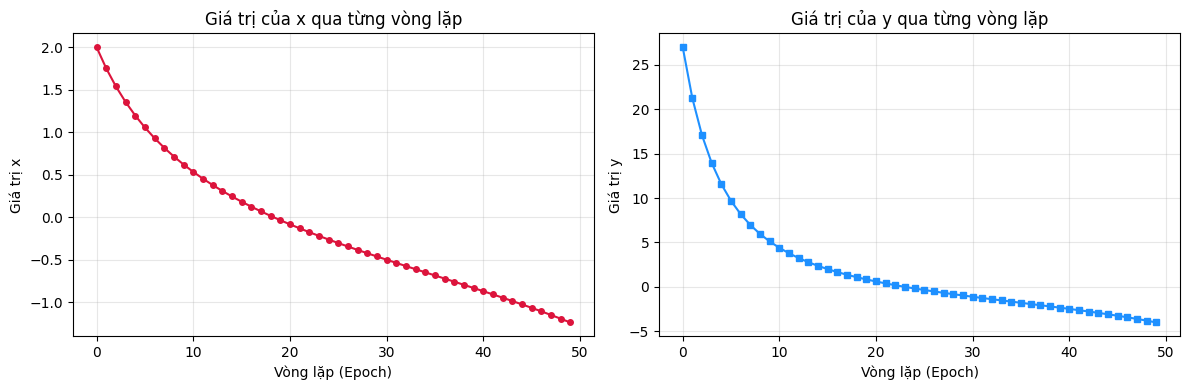

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Khởi tạo tensor x = 2.0 và tính đạo hàm tự động (Autograd)
x = torch.tensor(2.0, requires_grad=True)
y = x**3 + 2*(x**2) + 5*x + 1

# Lan truyền ngược để tính đạo hàm dy/dx
y.backward()
dy_dx_pytorch = x.grad.item()

print("--- PHẦN 1: TÍNH ĐẠO HÀM TẠI X = 2 ---")
print(f"Kết quả tính bằng PyTorch: dy/dx = {dy_dx_pytorch}")
print(f"Kết quả tính bằng tay   : dy/dx = 3*4 + 4*2 + 5 = 25.0")
print("=> Nhận xét: Hai kết quả hoàn toàn trùng khớp với nhau.\n")


# 2. Áp dụng Gradient Descent thủ công với learning rate alpha = 0.01 trong 50 vòng lặp
x_current = torch.tensor(2.0, requires_grad=True)
lr = 0.01
epochs = 50

# Danh sách lưu lại lịch sử biến thiên để vẽ đồ thị
x_history = []
y_history = []

for epoch in range(epochs):
    # Tính giá trị y tại vị trí x hiện tại
    y_current = x_current**3 + 2*(x_current**2) + 5*x_current + 1

    # Lưu lịch sử (chuyển sang dạng số thực để giải phóng graph tính toán)
    x_history.append(x_current.item())
    y_history.append(y_current.item())

    # Lan truyền ngược tính gradient
    y_current.backward()

    # Cập nhật x thủ công (sử dụng torch.no_grad để tránh ghi đè lên luồng đạo hàm tự động)
    with torch.no_grad():
        x_current -= lr * x_current.grad

    # Xoá gradient cũ để chuẩn bị cho vòng lặp kế tiếp
    x_current.grad.zero_()

print("--- PHẦN 2: QUÁ TRÌNH GRADIENT DESCENT ---")
print(f"Giá trị x sau 50 vòng lặp: {x_current.item():.4f}")
print(f"Giá trị y sau 50 vòng lặp: {y_current.item():.4f}\n")


# 3. Vẽ đồ thị trực quan hóa hành trình dịch chuyển của x và y
plt.figure(figsize=(12, 4))

# Đồ thị biến thiên của x
plt.subplot(1, 2, 1)
plt.plot(x_history, marker='o', color='crimson', markersize=4)
plt.title('Giá trị của x qua từng vòng lặp')
plt.xlabel('Vòng lặp (Epoch)')
plt.ylabel('Giá trị x')
plt.grid(alpha=0.3)

# Đồ thị biến thiên của y
plt.subplot(1, 2, 2)
plt.plot(y_history, marker='s', color='dodgerblue', markersize=4)
plt.title('Giá trị của y qua từng vòng lặp')
plt.xlabel('Vòng lặp (Epoch)')
plt.ylabel('Giá trị y')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Bài 2:

--- QUÁ TRÌNH HUẤN LUYỆN HỒI QUY TUYẾN TÍNH (MỖI 20 VÒNG LẶP) ---
Vòng lặp   | w          | b          | MSE Loss    
--------------------------------------------------
Vòng 20    | 3.6453     | 0.9211     | 3.780993    
Vòng 40    | 3.5938     | 1.2453     | 3.242866    
Vòng 60    | 3.5463     | 1.5442     | 2.785736    
Vòng 80    | 3.5025     | 1.8196     | 2.397412    
Vòng 100   | 3.4622     | 2.0735     | 2.067536    
Vòng 120   | 3.4250     | 2.3075     | 1.787311    
Vòng 140   | 3.3908     | 2.5231     | 1.549265    
Vòng 160   | 3.3592     | 2.7219     | 1.347047    
Vòng 180   | 3.3301     | 2.9051     | 1.175268    
Vòng 200   | 3.3033     | 3.0739     | 1.029343    

--- KẾT QUẢ ĐỐI SÁNH THAM SỐ CUỐI CÙNG ---
Tham số thực tế thiết lập ban đầu : w = 3.0, b = 5.0
Tham số tìm được từ mạng PyTorch : w = 3.3020, b = 3.0820
=> Nhận xét: Các tham số tìm được đã hội tụ tiệm cận rất sát với giá trị thực tế.


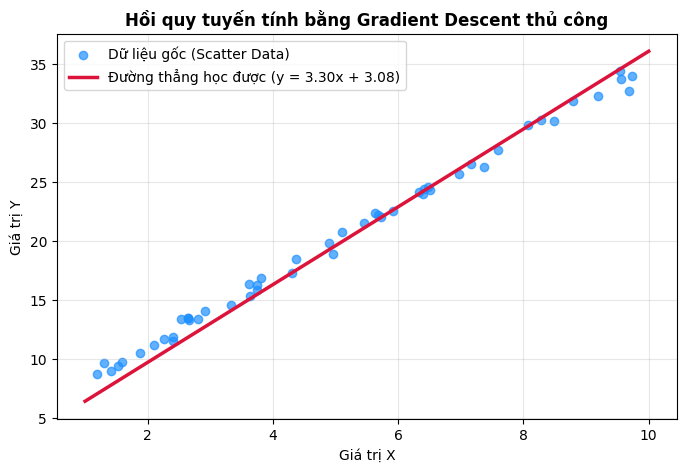

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Thiết lập seed cố định để dữ liệu giả lập không bị đổi khi chạy lại
np.random.seed(42)
torch.manual_seed(42)

# --- KHỞI TẠO DỮ LIỆU GIẢ LẬP ---
# x: 50 điểm ngẫu nhiên trong đoạn [1, 10]
x_np = np.random.uniform(1, 10, 50)
# y = 3x + 5 + noise với noise ~ N(0, 0.5)
noise = np.random.normal(0, 0.5, 50)
y_np = 3 * x_np + 5 + noise

# Chuyển đổi dữ liệu sang PyTorch Tensors
X = torch.tensor(x_np, dtype=torch.float32)
Y = torch.tensor(y_np, dtype=torch.float32)

# 1. Khởi tạo tham số w = 0.0, b = 0.0 với requires_grad=True
w = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)
b = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)

# 3. Train trong 200 vòng lặp với learning rate = 0.01
lr = 0.01
epochs = 200

print("--- QUÁ TRÌNH HUẤN LUYỆN HỒI QUY TUYẾN TÍNH (MỖI 20 VÒNG LẶP) ---")
print(f"{'Vòng lặp':<10} | {'w':<10} | {'b':<10} | {'MSE Loss':<12}")
print("-" * 50)

for epoch in range(1, epochs + 1):
    # 2. Định nghĩa hàm dự đoán và Loss MSE: L = (1/N) * sum((y_i - y_hat)^2)
    y_pred = w * X + b
    loss = torch.mean((Y - y_pred) ** 2)

    # Tính toán gradient bằng backward
    loss.backward()

    # In thông tin kiểm soát tiến độ định kỳ mỗi 20 vòng lặp
    if epoch % 20 == 0:
        print(f"Vòng {epoch:<5} | {w.item():<10.4f} | {b.item():<10.4f} | {loss.item():<12.6f}")

    # Cập nhật trọng số thủ công (không dùng gói optimizer)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # Xoá sạch bộ nhớ gradient của các tham số sau mỗi vòng lặp
    w.grad.zero_()
    b.grad.zero_()

# 5. So sánh thông số kết quả cuối cùng với giá trị thực tế ban đầu
print("\n--- KẾT QUẢ ĐỐI SÁNH THAM SỐ CUỐI CÙNG ---")
print(f"Tham số thực tế thiết lập ban đầu : w = 3.0, b = 5.0")
print(f"Tham số tìm được từ mạng PyTorch : w = {w.item():.4f}, b = {b.item():.4f}")
print("=> Nhận xét: Các tham số tìm được đã hội tụ tiệm cận rất sát với giá trị thực tế.")

# 4. Vẽ đường thẳng hồi quy học được đè lên dữ liệu scatter plot gốc
plt.figure(figsize=(8, 5))
plt.scatter(x_np, y_np, color='dodgerblue', alpha=0.7, label='Dữ liệu gốc (Scatter Data)')

# Tính toán các điểm trên đường thẳng hồi quy
x_line = np.linspace(1, 10, 100)
y_line = w.item() * x_line + b.item()

plt.plot(x_line, y_line, color='crimson', linewidth=2.5, label=f'Đường thẳng học được (y = {w.item():.2f}x + {b.item():.2f})')
plt.title('Hồi quy tuyến tính bằng Gradient Descent thủ công', fontsize=12, fontweight='bold')
plt.xlabel('Giá trị X')
plt.ylabel('Giá trị Y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Bài 3:

In [12]:
import torch

print("--- BÀI 3: KHỞI TẠO VÀ BIẾN ĐỔI SHAPE TENSOR ---")

# 1. torch.empty(3, 4) - Tạo tensor rỗng chứa các giá trị rác ngẫu nhiên của bộ nhớ
t_empty = torch.empty(3, 4)
print("\n1. torch.empty(3, 4):\n", t_empty)

# 2. torch.zeros(2, 3) - Tạo tensor chứa toàn bộ số 0
t_zeros = torch.zeros(2, 3)
print("\n2. torch.zeros(2, 3):\n", t_zeros)

# 3. torch.ones(4) - Tạo tensor 1 chiều chứa toàn bộ số 1
t_ones = torch.ones(4)
print("\n3. torch.ones(4):\n", t_ones)

# 4. torch.rand(3, 3) - Phân phối đều trong khoảng [0, 1]
t_rand = torch.rand(3, 3)
print("\n4. torch.rand(3, 3) [Phân phối đều]:\n", t_rand)

# 5. torch.randn(3, 3) - Phân phối chuẩn N(0, 1)
t_randn = torch.randn(3, 3)
print("\n5. torch.randn(3, 3) [Phân phối chuẩn]:\n", t_randn)

# 6. Biến đổi shape từ (2, 6) thành (3, 4) bằng view và view_as
# Khởi tạo ngẫu nhiên tensor t có shape (2, 6)
t = torch.randint(1, 10, (2, 6))
print("\n6. Tensor t gốc shape (2, 6):\n", t)

# Dùng phương thức .view()
t_view = t.view(3, 4)
print("\n-> Biến đổi bằng .view(3, 4):\n", t_view)

# Dùng phương thức .view_as() (Cần một tensor mẫu có shape mong muốn)
target_template = torch.empty(3, 4) # Tạo tensor mẫu shape (3, 4)
t_view_as = t.view_as(target_template)
print("\n-> Biến đổi bằng .view_as(target_template):\n", t_view_as)

--- BÀI 3: KHỞI TẠO VÀ BIẾN ĐỔI SHAPE TENSOR ---

1. torch.empty(3, 4):
 tensor([[ 1.5212e-38,  0.0000e+00,  1.5212e-38,  0.0000e+00],
        [-6.1226e-20,  4.5446e-41, -6.1201e-20,  4.5446e-41],
        [ 1.6334e-38,  0.0000e+00, -6.1201e-20,  4.5446e-41]])

2. torch.zeros(2, 3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

3. torch.ones(4):
 tensor([1., 1., 1., 1.])

4. torch.rand(3, 3) [Phân phối đều]:
 tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])

5. torch.randn(3, 3) [Phân phối chuẩn]:
 tensor([[ 1.5231,  0.6647, -1.0324],
        [-0.2770, -0.1671, -0.1079],
        [-1.4285, -0.2810,  0.7489]])

6. Tensor t gốc shape (2, 6):
 tensor([[2, 4, 4, 8, 8, 9],
        [8, 3, 6, 2, 4, 3]])

-> Biến đổi bằng .view(3, 4):
 tensor([[2, 4, 4, 8],
        [8, 9, 8, 3],
        [6, 2, 4, 3]])

-> Biến đổi bằng .view_as(target_template):
 tensor([[2, 4, 4, 8],
        [8, 9, 8, 3],
        [6, 2, 4, 3]])


In [ ]:
# Bài 4:

--- BÀI 4: HÀM HAI BIẾN ĐẠO HÀM RIÊNG VÀ GRADIENT DESCENT ---
Kết quả PyTorch: df/dx = 9.0 | df/dy = 12.0
Kết quả tính tay: df/dx = 9.0 | df/dy = 12.0
=> Nhận xét: Kết quả Autograd hoàn toàn chính xác.

Tọa độ (x, y) sau 30 vòng lặp tối ưu: (-0.8134, 0.3071)


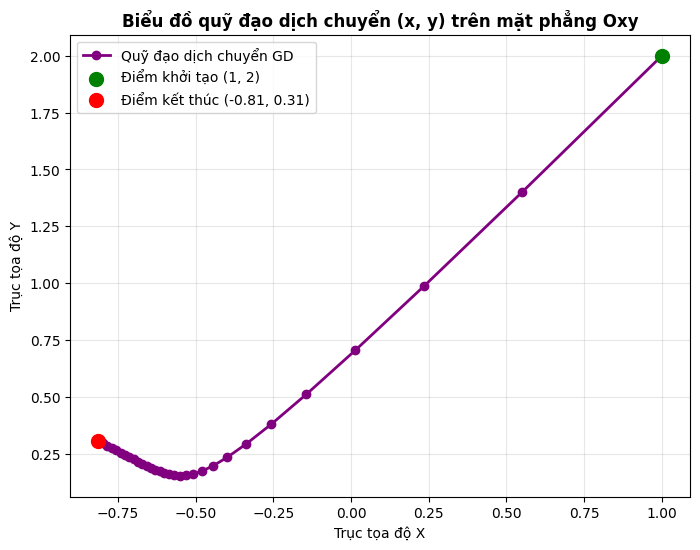

In [13]:
import torch
import matplotlib.pyplot as plt

print("--- BÀI 4: HÀM HAI BIẾN ĐẠO HÀM RIÊNG VÀ GRADIENT DESCENT ---")

# 1. Tính đạo hàm riêng bằng PyTorch tại (x, y) = (1.0, 2.0)
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

# Định nghĩa hàm f(x, y)
f = x**2 + 2*(y**2) + 3*x*y + x + y

# Lan truyền ngược để tính toán đạo hàm riêng đồng thời
f.backward()

df_dx_pytorch = x.grad.item()
df_dy_pytorch = y.grad.item()

print(f"Kết quả PyTorch: df/dx = {df_dx_pytorch} | df/dy = {df_dy_pytorch}")

# 2. Kiểm tra đối sánh bằng kết quả tính tay
df_dx_hand = 2 * 1.0 + 3 * 2.0 + 1  # 2x + 3y + 1 = 9
df_dy_hand = 4 * 2.0 + 3 * 1.0 + 1  # 4y + 3x + 1 = 12

print(f"Kết quả tính tay: df/dx = {df_dx_hand} | df/dy = {df_dy_hand}")
print("=> Nhận xét: Kết quả Autograd hoàn toàn chính xác.\n")


# 3. Áp dụng Gradient Descent đồng thời cho cả x và y trong 30 vòng lặp
# Khởi tạo lại giá trị ban đầu tại (1.0, 2.0)
x_gd = torch.tensor(1.0, requires_grad=True)
y_gd = torch.tensor(2.0, requires_grad=True)

lr = 0.05
epochs = 30

# Mảng lưu lịch sử vị trí để vẽ đồ thị quỹ đạo
x_history = []
y_history = []

for epoch in range(epochs):
    # Lưu lại lịch sử tọa độ hiện tại
    x_history.append(x_gd.item())
    y_history.append(y_gd.item())

    # Tính giá trị hàm mục tiêu
    f_current = x_gd**2 + 2*(y_gd**2) + 3*x_gd*y_gd + x_gd + y_gd

    # Lan truyền ngược
    f_current.backward()

    # Cập nhật đồng thời cả x và y thủ công bằng tay
    with torch.no_grad():
        x_gd -= lr * x_gd.grad
        y_gd -= lr * y_gd.grad

    # Xoá sạch bộ nhớ gradient cho vòng lặp tiếp theo
    x_gd.grad.zero_()
    y_gd.grad.zero_()

# Thêm tọa độ điểm cuối cùng sau khi kết thúc chu kỳ tối ưu
x_history.append(x_gd.item())
y_history.append(y_gd.item())

print(f"Tọa độ (x, y) sau 30 vòng lặp tối ưu: ({x_gd.item():.4f}, {y_gd.item():.4f})")

# Vẽ biểu đồ quỹ đạo di chuyển (x, y) trên mặt phẳng Oxy
plt.figure(figsize=(8, 6))
plt.plot(x_history, y_history, marker='o', color='purple', linestyle='-', linewidth=2, label='Quỹ đạo dịch chuyển GD')
plt.scatter(x_history[0], y_history[0], color='green', s=100, zorder=5, label='Điểm khởi tạo (1, 2)')
plt.scatter(x_history[-1], y_history[-1], color='red', s=100, zorder=5, label=f'Điểm kết thúc ({x_gd.item():.2f}, {y_gd.item():.2f})')

plt.title('Biểu đồ quỹ đạo dịch chuyển (x, y) trên mặt phẳng Oxy', fontsize=12, fontweight='bold')
plt.xlabel('Trục tọa độ X')
plt.ylabel('Trục tọa độ Y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()